<a href="https://colab.research.google.com/github/mdaugherity/Numerical2026/blob/main/errors/Week_1_How_Numbers_are_Stored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PHYS 351 - Applied Numerical

Examples for how computers store numbers.  The moral for today:

**COMPUTERS STORE APPROXIMATE VALUES, NOT EQUATIONS!**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Warm-up
Make this plot

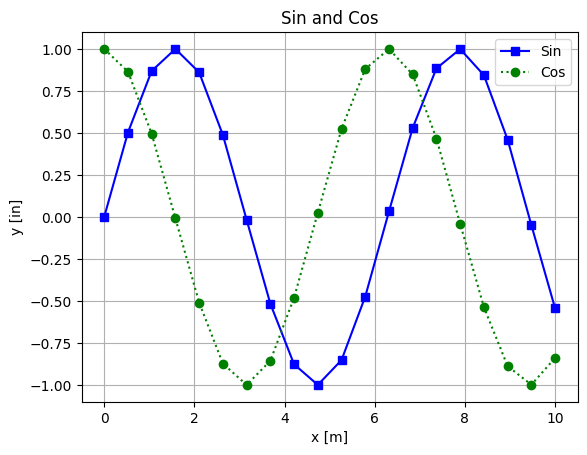

In [2]:
x = np.linspace(0,10,20)
y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x,y1,'b-s',label='Sin')
plt.plot(x,y2,'g:o',label='Cos')

plt.title('Sin and Cos')
plt.xlabel('x [m]')
plt.ylabel('y [in]')
plt.grid()

plt.legend()
plt.show()

# The Problem
Math is not exact in a computer!  Why?  Because the computer can only store 64-bit approximations of numbers

In [3]:
2.6 + 0.6

3.2

In [4]:
2.6 + 0.2 + 0.2 + 0.2

3.2000000000000006

In [5]:
(2)**0.5

1.4142135623730951

In [6]:
(2)**0.5 * (2)**0.5

2.0000000000000004

In [7]:
(2)**0.5 * (2)**0.5 - 2

4.440892098500626e-16

# Representation
You need to be comfortable with binary (base 2) and hex (base 16).  Python can help.

In [8]:
bin(26)

'0b11010'

In [9]:
0b11010

26

In [10]:
0b0010101011001011010101010110101011010

22974999898

In [11]:
4*256+11*16+7

1207

In [12]:
0x4B7

1207

In [13]:
bin(1207)


'0b10010110111'

In [14]:
bin(1207)

'0b10010110111'

In [15]:
2**1023

89884656743115795386465259539451236680898848947115328636715040578866337902750481566354238661203768010560056939935696678829394884407208311246423715319737062188883946712432742638151109800623047059726541476042502884419075341171231440736956555270413618581675255342293149119973622969239858152417678164812112068608

In [16]:
2**-1023

1.1125369292536007e-308

In [17]:
float.hex(26.0)

'0x1.a000000000000p+4'

In [18]:
print( float.hex((2**0.5)  * (2**0.5)) )
print( float.hex(2.0) )

0x1.0000000000001p+1
0x1.0000000000000p+1


**PRACTICE:** what is 0xCAFE in base-10?

In [19]:
#0xCAFE

In [33]:
a = 42
print(f"int: {a:d};  hex: {a:x};  oct: {a:o};  bin: {a:b}")
print(f"int: {a:d};  hex: {a:#x};  oct: {a:#o};  bin: {a:#b}")  # option to turn on prefix

int: 42;  hex: 2a;  oct: 52;  bin: 101010
int: 42;  hex: 0x2a;  oct: 0o52;  bin: 0b101010


# Machine Epsilon
Find the **largest** possible number that we can add to 1 and not change any bits:   
$1 + ϵ = 1$


In [21]:
1 + 1e-16

1.0

In [22]:
print( float.hex(1.0))
print( float.hex(1.0 + 1e-10))
print( float.hex(1.0 + 1e-15))
print( float.hex(1.0 + 1e-16))

0x1.0000000000000p+0
0x1.000000006df38p+0
0x1.0000000000005p+0
0x1.0000000000000p+0


In [23]:
np.finfo(float).eps

np.float64(2.220446049250313e-16)

In [24]:
np.finfo(float)

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

# Equality
WARNING!  Danger lies below.

In [25]:
x = 3.2
y = 2.6 + 0.2 + 0.2 + 0.2
if(x==y):
  print("equal")
else:
  print("nope")

nope


In [26]:
x = 2
y = (2)**0.5 * (2)**0.5
print(x==y)

False


BE VERY CAREFUL in checking if two floating-point numbers are equal!

**NEVER** just check for x==y, instead check that they are close enough


In [27]:
x==y

False

In [28]:
np.abs(x-y)<1e-12

np.True_

In [29]:
np.allclose(x,y)

True

Reference: https://numpy.org/doc/stable/reference/generated/numpy.allclose.html

You can specify a tolerance about how close is *close enough*.  Default absolute tolerance is 1e-8


# Sumup vs Sumdown
A nefarious example

In [30]:
# Sum up vs sum down
N = 1000
sumup = 0
for i in range(1,N):   # make sure to skip zero!
  sumup+=1/i

sumdown = 0
for i in range(N-1,0,-1):  # counts down from N-1 to 1
  sumdown +=1/i

print(sumup)
print(sumdown)
print(sumup-sumdown)

7.484470860550343
7.484470860550341
1.7763568394002505e-15


Plot version 1

1000
10000
100000
1000000


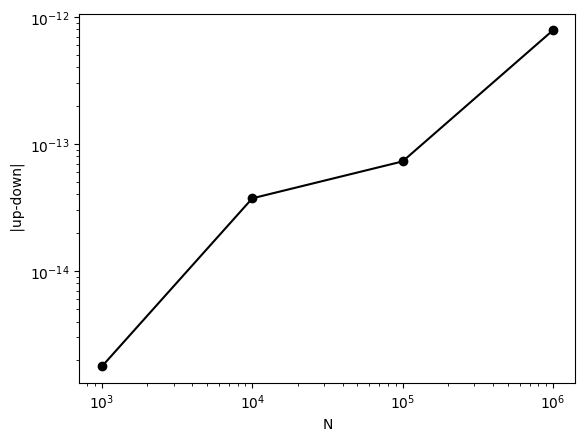

In [31]:
NLIST = [1000, 10000, 100000, 1000000]
NUM = len(NLIST)

ups = np.zeros(NUM)
downs = np.zeros(NUM)

for i in range(NUM):
  N = NLIST[i]
  print(N)
  sumup = 0
  for j in range(1,N):   # make sure to skip zero!
    sumup+=1/j
  ups[i] = sumup

  sumdown = 0
  for j in range(N-1,0,-1):  # counts down from N-1 to 1
    sumdown +=1/j
  downs[i] = sumdown

diff = np.abs(ups - downs)

plt.loglog(NLIST, diff,'ko-')
plt.xlabel('N')
plt.ylabel(' |up-down|')
plt.show()

Plot version 2

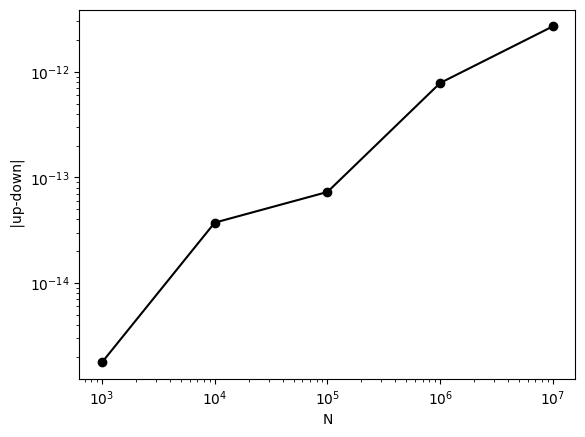

In [32]:
NLIST = np.logspace(3,7,5)
NUM = len(NLIST)

ups = np.zeros(NUM)
downs = np.zeros(NUM)

for i in range(NUM):
  N = int(NLIST[i])
  #print(N)
  sumup = 0
  for j in range(1,N):   # make sure to skip zero!
    sumup+=1/j
  ups[i] = sumup

  sumdown = 0
  for j in range(N-1,0,-1):  # counts down from N-1 to 1
    sumdown +=1/j
  downs[i] = sumdown

diff = np.abs(ups - downs)

plt.loglog(NLIST, diff,'ko-')
plt.xlabel('N')
plt.ylabel(' |up-down|')
plt.show()